In [1]:
import sys
sys.path.append("..")  # utilsは1階層上にある

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from utils.models import LSTMGaussian,PortfolioLSTMModel
from utils.trainer import DreamingTrainer
from utils.datawindow import TorchDataWindow
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

In [2]:
# データ読み込み
df = pd.read_csv('../data/100stock_data.csv')
# date列を削除
df = df.drop(columns=['date'])
# 対数収益
prices = df.astype(float).values
logret = np.diff(np.log(prices), axis=0)        # [L-1, 100]
cols = list(df.columns)

target_col = 0
y   = logret[:, [target_col]]                   # ← ここを [] で2次元に（[L-1,1]）
exo = np.delete(logret, target_col, axis=1)     # [L-1, 99]

seq_single = np.concatenate([y, exo], axis=1)   # [L-1, 100]
data_single = [seq_single.astype(np.float32)]
D = data_single[0].shape[1]

data_all = []
for c in range(logret.shape[1]):
    y_c   = logret[:, [c]]
    exo_c = np.delete(logret, c, axis=1)
    seq_c = np.concatenate([y_c, exo_c], axis=1).astype(np.float32)  # [L-1, 100]
    data_all.append(seq_c)
# 使うモードを選ぶ：
use_all_targets = False
data = data_all if use_all_targets else data_single
D    = data[0].shape[1]

#データ分割
# logret: [T, N]  (T=時点数, N=銘柄数)
test_len = 200

def split_train_test_seq(seq_2d, test_len):
    # seq_2d: [L, D]（列0=ターゲット, 列1..=外生）
    L = seq_2d.shape[0]
    assert test_len < L
    return seq_2d[:L-test_len], seq_2d[L-test_len:]

# 例：単一ターゲット＋外生（D=100）
seq = seq_single.astype(np.float32)         # [L, D]
train_seq, test_seq = split_train_test_seq(seq, test_len)

# 複数系列（全銘柄を個別に学習したい場合）
train_data = []
test_data  = []
for seq in data_all:                        # 各seq: [L, D]
    tr, te = split_train_test_seq(seq, test_len)
    train_data.append(tr); test_data.append(te)

In [5]:
#学習済みモデルとトレーナーの準備
import json
with open("../results/best_params.json", "r") as f:
    best = ("best", json.load(f))
PATH = "../models/dreaming_model.pth"
model = LSTMGaussian(input_dim=D, hidden_size=best[1]["hidden"],num_layers=best[1]["layers"],
                     proj_dim=best[1]["proj_dim"], dropout=best[1]["dropout"])
state_dict = torch.load(PATH)
model.load_state_dict(state_dict)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=best[1]["lr"])

trainer = DreamingTrainer(
    model=model, optimizer=optimizer, device=device,
    interleave_mode=best[1]["mode"], K_interleave=best[1]["K"],
    epochs=500,
    warm_vanilla_steps=500,
    max_vanilla_steps_per_epoch=200,
    dreaming_steps_per_epoch=50,
    dreaming_seq_len=50,
    lambda_d=0.2,
    temperature=best[1]["T"],
    temperature_schedule="constant",
    temperature_params=None,
    exo_mode="hold",
    grad_clip=1.0,
    logvar_clamp=(-20, 10),
    seed=42
)

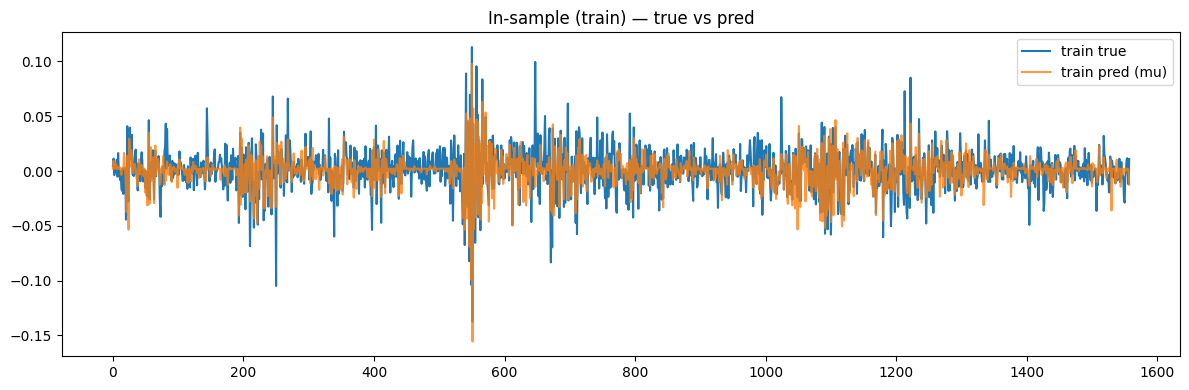

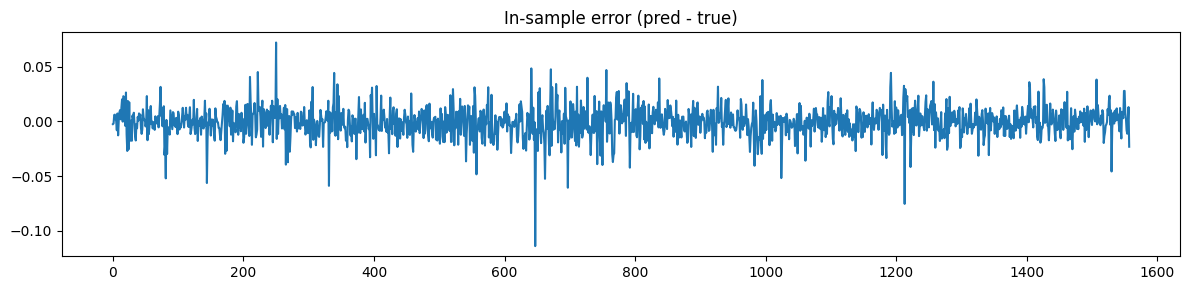

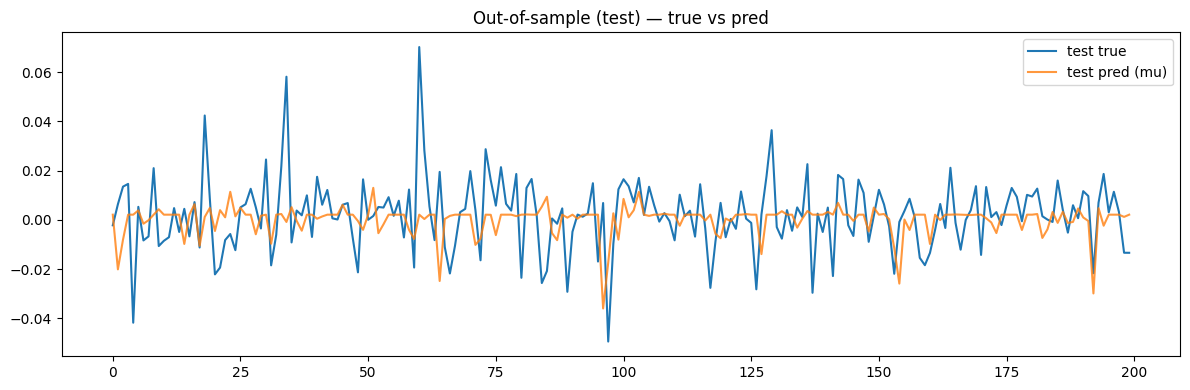

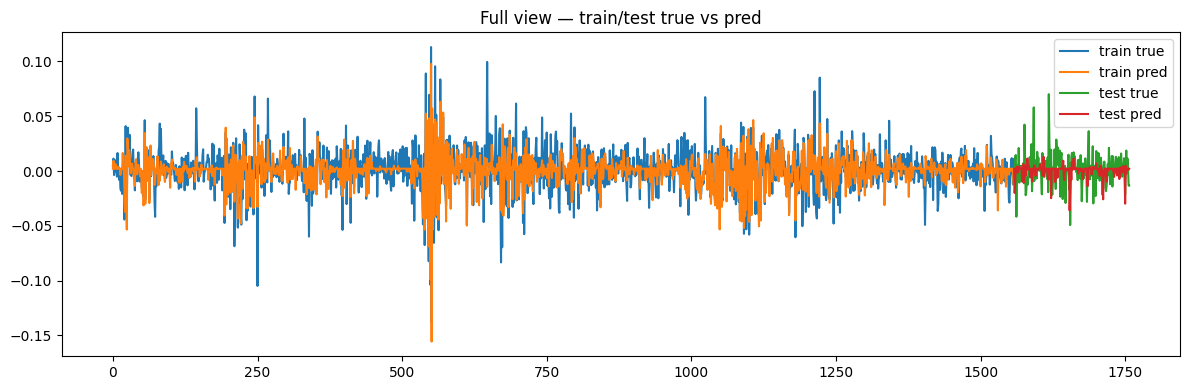

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# ==== 前提：data[0] が [L,D]（列0=ターゲット） ====
seq = data[0]
test_len = 200  # 後ろ200ステップをテストに

# --- 1) train 期間の当てはまり ---
train_arr, _ = trainer.split_train_test(seq, test_len)
ins = trainer.predict_in_sample(train_arr)  # y, y_hat, err

plt.figure(figsize=(12,4))
plt.plot(ins["y"], label="train true")
plt.plot(ins["y_hat"], label="train pred (mu)", alpha=0.8)
plt.title("In-sample (train) — true vs pred")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(12,3))
plt.plot(ins["err"])
plt.title("In-sample error (pred - true)")
plt.tight_layout(); plt.show()

# --- 2) test 期間の逐次予測 ---
oos = trainer.predict_out_of_sampleseq = data[0]
(oos := trainer.predict_out_of_sample(seq, test_len=test_len, use_mean=True, T=1.0))

plt.figure(figsize=(12,4))
plt.plot(oos["y"], label="test true")
plt.plot(oos["y_hat"], label="test pred (mu)", alpha=0.8)
plt.title("Out-of-sample (test) — true vs pred")
plt.legend(); plt.tight_layout(); plt.show()

# --- 3) 連結表示（オプション） ---
# trainの終端とtest予測をつなげて、全期間の可視化
y_train = ins["y"]
yhat_train = ins["y_hat"]
y_test = oos["y"]
yhat_test = oos["y_hat"]

plt.figure(figsize=(12,4))
plt.plot(np.arange(len(y_train)), y_train, label="train true")
plt.plot(np.arange(len(y_train)), yhat_train, label="train pred")
plt.plot(np.arange(len(y_train), len(y_train)+len(y_test)), y_test, label="test true")
plt.plot(np.arange(len(y_train), len(y_train)+len(y_test)), yhat_test, label="test pred")
plt.title("Full view — train/test true vs pred")
plt.legend(); plt.tight_layout(); plt.show()


In [7]:
#テストデータに対するMSE, MAEの計算
metrics_test = trainer.evaluate_metrics(test_data)
print(f"Test Data NLL: {metrics_test['nll']:.6f}")
print(f"Test Data MSE: {metrics_test['mse']:.6f}")
print(f"Test Data MAE: {metrics_test['mae']:.6f}")

Test Data NLL: -3.373038
Test Data MSE: 0.000342
Test Data MAE: 0.012437
